# Stacking-Based Ensemble for Heart Attack Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load & preprocess data

In [2]:
df = pd.read_csv("heart.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print("Missing values per column:\n", df.isnull().sum())
df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Train: (242, 13)  Test: (61, 13)


## 2. Base classifiers

In [4]:
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "KNN":                 KNeighborsClassifier(n_neighbors=7),
}

results = []
roc_data = {}

for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall":    recall_score(y_test, preds),
        "F1-Score":  f1_score(y_test, preds),
        "ROC-AUC":   roc_auc_score(y_test, probs),
    })
    roc_data[name] = roc_curve(y_test, probs)

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690
Decision Tree,0.7049,0.7027,0.7879,0.7429,0.6975
Random Forest,0.8197,0.7619,0.9697,0.8533,0.9123
XGBoost,0.8033,0.7561,0.9394,0.8378,0.8561
Naive Bayes,0.8197,0.7895,0.9091,0.8451,0.8755
KNN,0.8197,0.7895,0.9091,0.8451,0.8837


## 3. Stacking ensemble
Meta-classifier: Logistic Regression trained on out-of-fold predictions of the base models (5-fold internal CV, as in the paper).

In [5]:
estimators = [(name, model) for name, model in base_models.items()]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
)

stack_model.fit(X_train_scaled, y_train)
stack_preds = stack_model.predict(X_test_scaled)
stack_probs = stack_model.predict_proba(X_test_scaled)[:, 1]

stack_row = {
    "Model": "Stacking Ensemble",
    "Accuracy":  accuracy_score(y_test, stack_preds),
    "Precision": precision_score(y_test, stack_preds),
    "Recall":    recall_score(y_test, stack_preds),
    "F1-Score":  f1_score(y_test, stack_preds),
    "ROC-AUC":   roc_auc_score(y_test, stack_probs),
}
roc_data["Stacking Ensemble"] = roc_curve(y_test, stack_probs)

results_df = pd.concat([results_df, pd.DataFrame([stack_row]).set_index("Model")]).round(4)
results_df.sort_values("Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.8197,0.7619,0.9697,0.8533,0.9123
Naive Bayes,0.8197,0.7895,0.9091,0.8451,0.8755
KNN,0.8197,0.7895,0.9091,0.8451,0.8837
Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690
XGBoost,0.8033,0.7561,0.9394,0.8378,0.8561
Stacking Ensemble,0.8033,0.7692,0.9091,0.8333,0.8918
Decision Tree,0.7049,0.7027,0.7879,0.7429,0.6975


## 4. Results

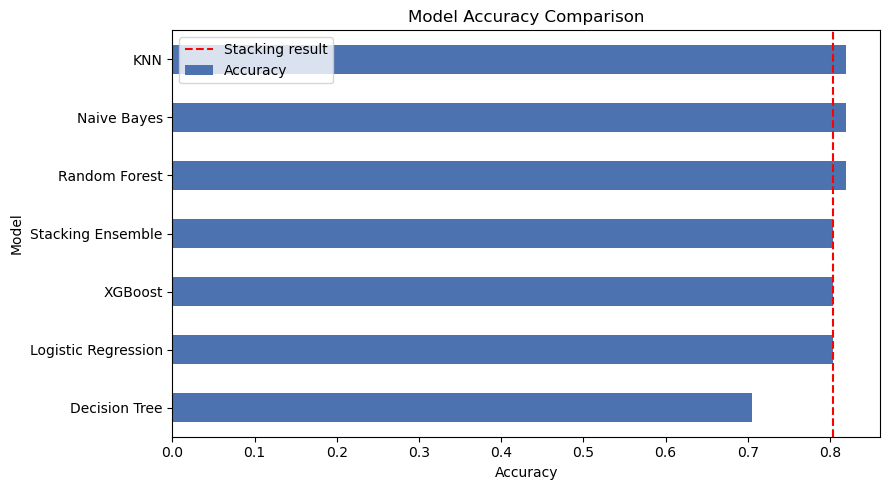

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
results_df["Accuracy"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
ax.axvline(results_df.loc["Stacking Ensemble", "Accuracy"], color="red", linestyle="--", label="Stacking result")
ax.legend()
plt.tight_layout()
plt.show()

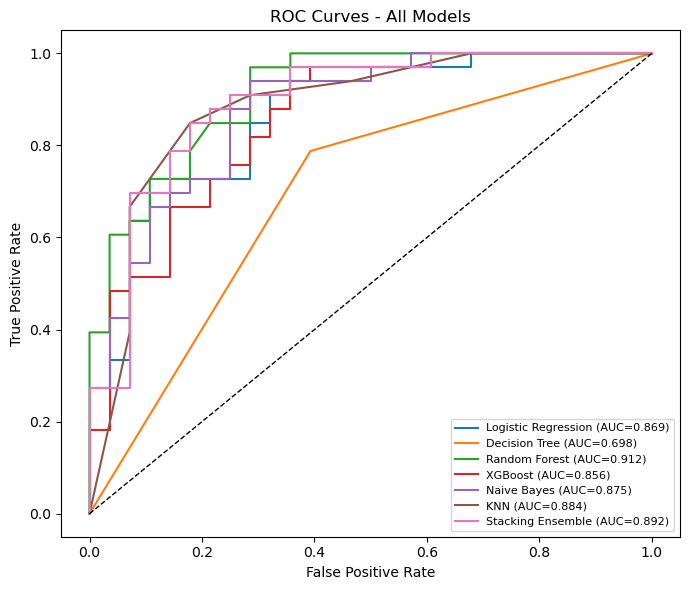

In [7]:
fig, ax = plt.subplots(figsize=(7,6))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[name, "ROC-AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

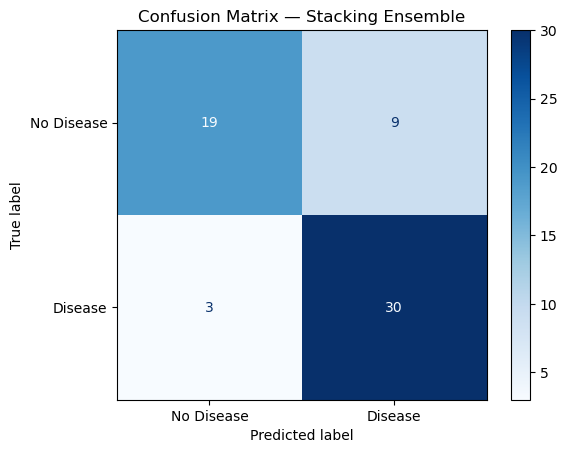

In [9]:
cm = confusion_matrix(y_test, stack_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Stacking Ensemble")
plt.show()